# S8: Introduction to Unsupervised Learning and Its Applications

By Phanuphat (Oad) Srisukhawasu

Machine Learning Department, NUS Fintech Society

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

# Set random seed for reproducibility
np.random.seed(42)

## Generate Example Data

In [2]:
# We generate 3D data using make_blobs, with 4 centers (clusters) by default
def generate_3d_blob_data(n_samples=500,
                          n_features=3,
                          centers=4,
                          cluster_std=1.0):
    X, y = make_blobs(n_samples=n_samples,
                      centers=centers,
                      n_features=n_features,
                      cluster_std=cluster_std,
                      random_state=42)
    return X, y

# Generate 3D data
X, y = generate_3d_blob_data()

## Plot Initial Data

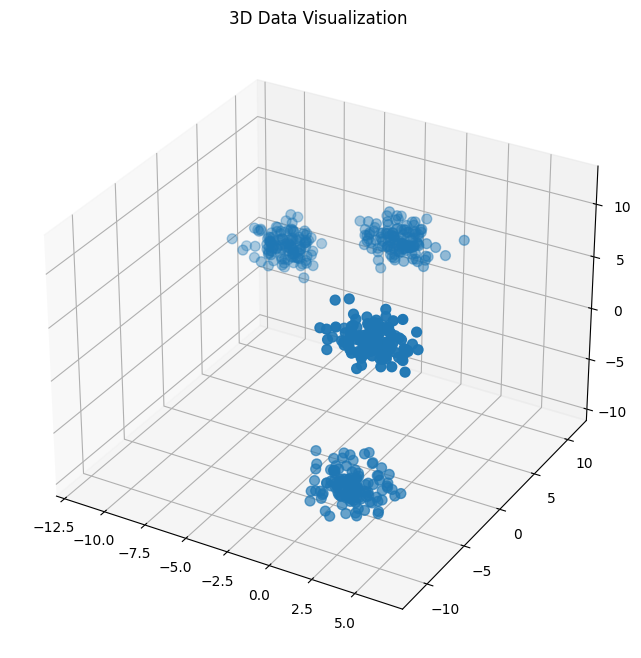

In [3]:
# We will create a 3D plot to visualize the raw data
def plot_3d_data(X, labels=None):
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    if labels is not None:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis', s=50)
    else:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=50)

    ax.set_title("3D Data Visualization")
    plt.show()

# Visualize the raw 3D data
plot_3d_data(X)

## K-Means Clustering

### Silhouette Score
The Silhouette Score is a metric used to measure the quality of clustering, helping to evaluate how well data points are grouped in clusters. It quantifies how similar a data point is to its own cluster (cohesion) compared to other clusters (separation). A higher silhouette score indicates that the data point is well-matched to its own cluster and poorly matched to neighboring clusters.

Formula:
The silhouette score for a single data point $i$ is given by: $$s(i)=\frac{b(i)-a(i)}{\text{max}(a(i), b(i))}$$

Where:

$a(i)$ = intra-cluster distance: The average distance between the point $i$ and all other points in the same cluster (how close $i$ is to other points in its own cluster).

$b(i)$ = nearest-cluster distance: The minimum average distance between the point $i$ and points in the nearest neighboring cluster (how close $i$ is to the points in the next best-fitting cluster).



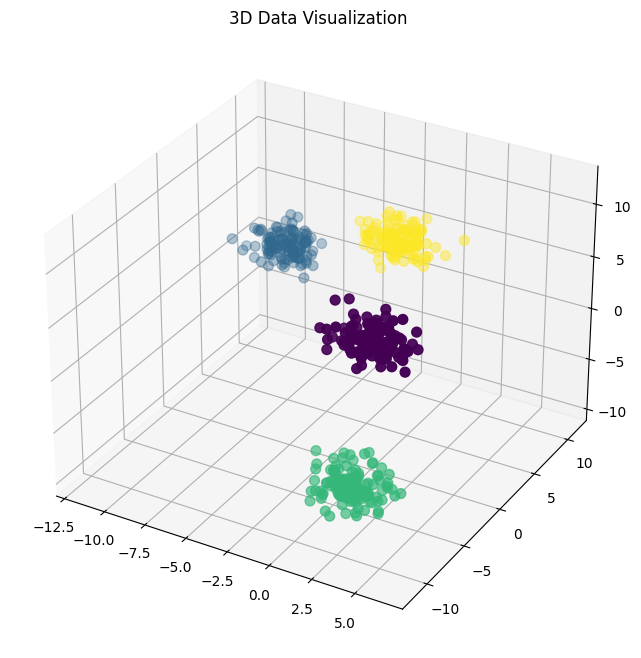

K-Means Silhouette Score: 0.778156591980226


In [4]:
def kmeans_clustering(X, n_clusters=4):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X)
    labels = kmeans.labels_
    return labels, kmeans

# Perform K-Means clustering on 3D data
kmeans_labels, kmeans = kmeans_clustering(X)
plot_3d_data(X, kmeans_labels)

print(f"K-Means Silhouette Score: {silhouette_score(X, kmeans_labels)}")

## DBSCAN Clustering

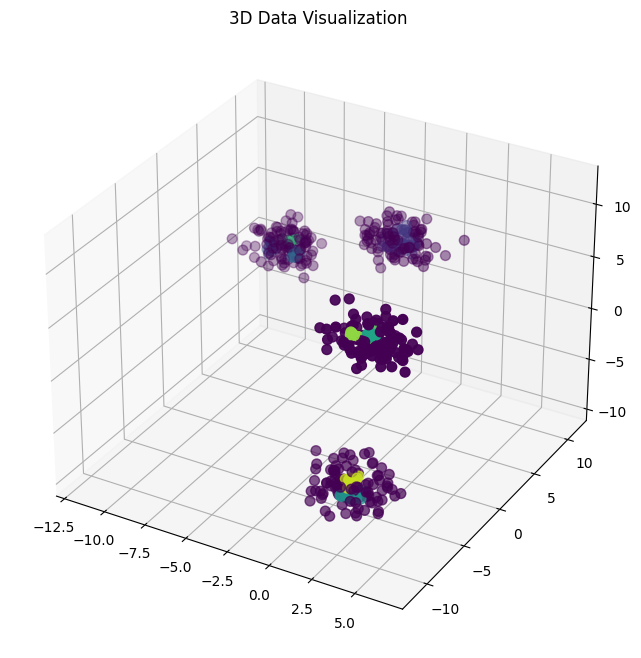

DBSCAN Silhouette Score: -0.5988585747683771


In [5]:
def dbscan_clustering(X, eps=0.5, min_samples=5):
    # Initialize DBSCAN with the given parameters
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)

    # Fit the model to the data
    labels = dbscan.fit_predict(X)

    # labels will contain cluster IDs for each point, where -1 means a point is considered noise (outlier)
    return labels, dbscan

# Perform DBSCAN clustering on 3D data
dbscan_labels, dbscan = dbscan_clustering(X)

# Visualize the clustering result in 3D
plot_3d_data(X, dbscan_labels)

print(f"DBSCAN Silhouette Score: {silhouette_score(X, dbscan_labels)}")

## PCA for Dimensionality Reduction

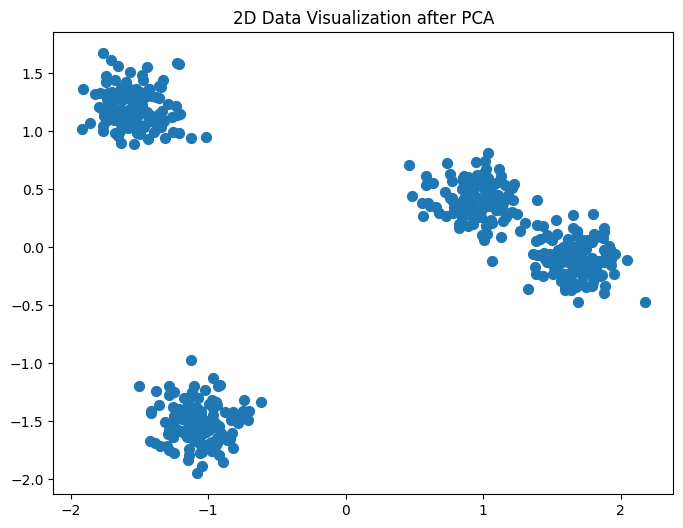

In [6]:
def pca_dimensionality_reduction(X, n_components=2):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    return X_pca, pca

# Perform PCA and reduce data to 2 dimensions
X_pca, pca = pca_dimensionality_reduction(X)

def plot_2d_data(X, labels=None):
    plt.figure(figsize=(8, 6))

    if labels is not None:
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
    else:
        plt.scatter(X[:, 0], X[:, 1], s=50)

    plt.title("2D Data Visualization after PCA")
    plt.show()

# Visualize the PCA-reduced data in 2D
plot_2d_data(X_pca)